<a href="https://colab.research.google.com/github/shadowcompiles/cap-comp215/blob/2026.01/EarthquakeDashboard.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Simple Earthquake Dashboard

Name: Kim Nouriyekdel

Date: 2026.03.06

Student ID: 100188938

---

In this project, I created a simple earthquake dashboard using data from the USGS Earthquake API.
The goal of the dashboard is to summarize earthquake data and display it using graphs.

The notebook fetches earthquake data from the API and then analyzes it to produce a few basic metrics.

The dashboard includes:
- The number of earthquakes per day
- The distribution of earthquake magnitudes
- The regions where earthquakes happen the most

The parameters below can be changed to customize the dashboard. After changing the values,
the user can rerun the notebook to update the graphs.

## How to Use the Dashboard

To customize the dashboard, we change the parameter values in the next code cell.
For example, we can change the minimum magnitude or the date range.

After changing the values, we run the notebook again to generate new graphs.

In [25]:
# Dashboard Parameters

MinMagnitude = 2.5
StartDate = "2024-01-01"
EndDate = "2024-01-07"
Region = "global"

In [26]:
import requests
import matplotlib.pyplot as plt
from datetime import datetime
from dataclasses import dataclass
from collections import Counter

In [27]:
@dataclass
class Earthquake:
    Magnitude: float
    Place: str
    Time: datetime

    @staticmethod
    def from_feature(feature):
        Props = feature["properties"]

        Magnitude = Props["mag"]
        Place = Props["place"]
        Time = datetime.fromtimestamp(Props["time"] / 1000)

        return Earthquake(Magnitude, Place, Time)

URL = ("https://earthquake.usgs.gov/fdsnws/event/1/query"
    f"?format=geojson&starttime={StartDate}&endtime={EndDate}&minmagnitude={MinMagnitude}")

Response = requests.get(URL)
Data = Response.json()

Features = Data["features"]

Earthquakes = [Earthquake.from_feature(f) for f in Features]

print("Total earthquakes found:", len(Earthquakes))

Total earthquakes found: 451


In [28]:
Dates = [eq.Time.date() for eq in Earthquakes]

DateCounts = Counter(Dates)

DatesSorted = sorted(DateCounts.keys())
counts = [DateCounts[d] for d in DatesSorted]

Magnitudes = [eq.Magnitude for eq in Earthquakes]

Regions = [eq.Place.split(",")[-1].strip() for eq in Earthquakes]

RegionCounts = Counter(Regions)

TopRegions = RegionCounts.most_common(5)

RegionNames = [r[0] for r in TopRegions]
RegionValues = [r[1] for r in TopRegions]

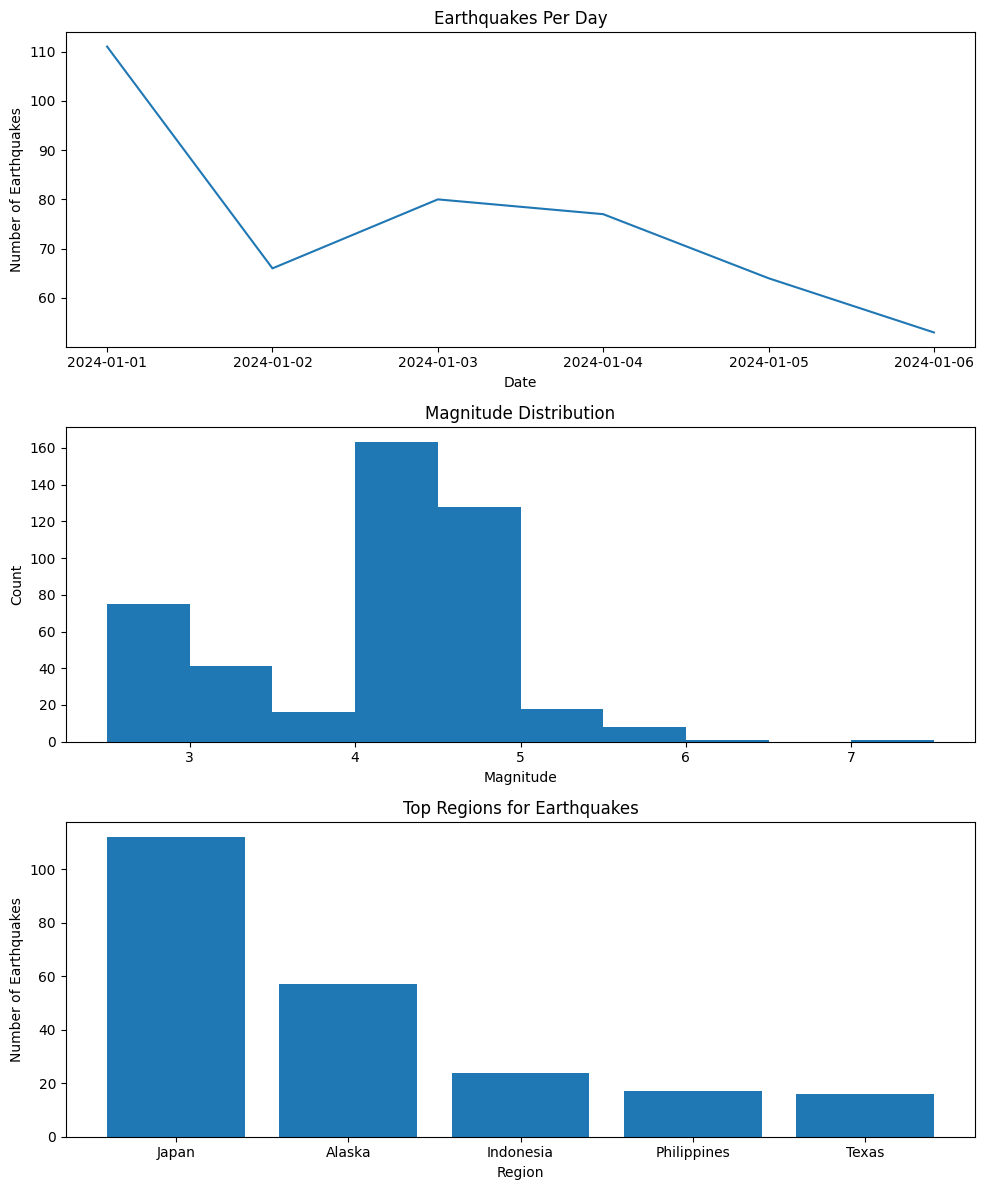

In [29]:
fig, axs = plt.subplots(3, 1, figsize=(10, 12))

# Graph 1: Earthquakes per day
axs[0].plot(DatesSorted, counts)
axs[0].set_title("Earthquakes Per Day")
axs[0].set_xlabel("Date")
axs[0].set_ylabel("Number of Earthquakes")

# Graph 2: Magnitude distribution
axs[1].hist(Magnitudes, bins=10)
axs[1].set_title("Magnitude Distribution")
axs[1].set_xlabel("Magnitude")
axs[1].set_ylabel("Count")

# Graph 3: Top regions for earthquakes
axs[2].bar(RegionNames, RegionValues)
axs[2].set_title("Top Regions for Earthquakes")
axs[2].set_xlabel("Region")
axs[2].set_ylabel("Number of Earthquakes")

plt.tight_layout()
plt.show()

## Results

The dashboard shows three main earthquake statistics.

The first graph shows how many earthquakes happened each day in the selected time period.
This helps show how earthquake activity changes over time.

The second graph shows the distribution of earthquake magnitudes. Most earthquakes
usually have smaller magnitudes.

The third graph shows which regions had the most earthquakes during the selected time period.

By changing the parameters at the top of the notebook, the user can generate different
results and explore earthquake activity for different dates or magnitude ranges.